# 比較Babu論文與我的方法差異
太陽黑子

Babu的方法

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
from scipy.stats import kurtosis, t

import yfinance as yf
import datetime as dt

import tensorflow as tf
from tensorflow import keras


import random
from statsmodels.tsa.arima.model import ARIMA


ModuleNotFoundError: No module named 'yfinance'

In [ ]:
class config:    
    train_n = 80
    test_n = 20
    seed = 111
    n_samples = train_n+test_n
    train_prob = 0.8
    n_1 = 0.1 # MA_filter最長取到多長
    Bootstrap = 100

           Date  sunspot
1812 1900-01-01     15.7
1813 1900-02-01     22.8
1814 1900-03-01     14.4
1815 1900-04-01     26.8
1816 1900-05-01     25.3 

            Date  sunspot
3284 2022-09-01     96.0
3285 2022-10-01     95.5
3286 2022-11-01     80.5
3287 2022-12-01    112.8
3288 2023-01-01    144.4


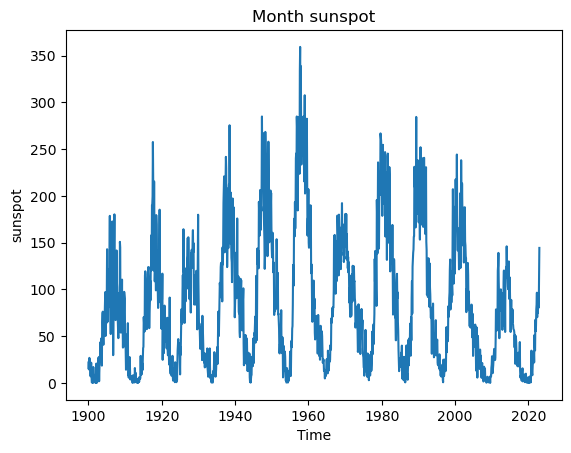

In [ ]:
# sunspot

cleaned_data = {
    'Year': [],
    'Month': [],
    'sunspot': [],
}

with open('SN_m_tot_V2.0.csv', 'r') as file:
    reader = csv.reader(file, delimiter=';')
    
    for row in reader:
        cleaned_data['Year'].append(row[0])
        cleaned_data['Month'].append(row[1])
        cleaned_data['sunspot'].append(row[3])


df_sunspot = pd.DataFrame(cleaned_data)

df_sunspot['Date'] = df_sunspot['Year'] + '-' + df_sunspot['Month']

df_sunspot = df_sunspot.drop(['Year', 'Month'], axis=1)
df_sunspot = df_sunspot[['Date', 'sunspot']]

df_sunspot['sunspot'] = pd.to_numeric(df_sunspot['sunspot'])
df_sunspot['Date'] = pd.to_datetime(df_sunspot['Date'], format='%Y-%m')

# 用1900-01後到2023-01的資料就好
df_sunspot = df_sunspot[(df_sunspot['Date'] >= '1900-01-01') & (df_sunspot['Date'] <= '2023-01-01')]
print(df_sunspot.head(),'\n\n',df_sunspot.tail())

plt.plot(df_sunspot['Date'],df_sunspot['sunspot'])
plt.xlabel('Time')
plt.ylabel('sunspot')
plt.title('Month sunspot')
plt.show()

In [ ]:
def kalman_filter(observations):
    # 初始化卡爾曼濾波器的參數(1維的模型，我們將H設為1後省略)
    initial_estimate = observations[0]  # 初始狀態估計
    initial_estimate_error = 1  # 初始估計的不確定性
    process_variance = 0.5  # 系統模型的不確定性（系統噪聲方差） (Q)
    measurement_variance = 10  # 觀測模型的不確定性（觀測噪聲方差）(R)

    # 初始化卡爾曼濾波器估計
    estimated_state = initial_estimate
    estimate_error = initial_estimate_error

    # 存儲估計值的歷史
    estimated_states = []
    
    # 存儲errors的歷史
    estimate_errors = []

    # 開始卡爾曼濾波過程
    for measurement in observations:
        # 預測步驟
        predicted_state = estimated_state      # 先驗 X
        predict_error = estimate_error + process_variance # 去預測K+1期的標準差，可以開信賴區間    #先驗 P

        # 更新步驟
        kalman_gain = predict_error / (predict_error + measurement_variance)    # K
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)    # X
        estimate_error = (1 - kalman_gain) * predict_error           # P

        estimated_states.append(estimated_state)
        estimate_errors.append(estimate_error)
  
    return estimated_states 

def MA_filter(observations,n):
    # MA_filter會損失n-1個樣本
    MA_filter = np.convolve(observations, np.ones(n)/n, mode='valid')  
    
    return MA_filter



def seed_everything(seed):
    # Set Python random seed
    random.seed(seed)
    
    # Set NumPy random seed
    np.random.seed(seed)
    
    tf.random.set_seed(seed)
    
# 製造滯後數據
def create_dataset(dataset,look_back):
    X, Y = [], []
    for i in range(len(dataset)-look_back):
        X.append(dataset[i:(i+look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)


# 在ARIMA(p,0,q)，p=0,...,5，q=0,...,5，找AIC最小的model
def find_order(dataset):
    # p，q取太大的話會出現 LinAlgError: LU decomposition error.
    p_range = range(0, 5)  # AR
    q_range = range(0, 5)  # MA

    best_aic = np.inf
    best_params = None

    # 進行參數搜索
    for p in p_range:
        for q in q_range:
            model = ARIMA(dataset, order=(p, 0, q))
            results = model.fit()
            aic = results.aic
            if aic < best_aic:
                best_aic = aic
                best_params = (p, q)

    return best_params

# dataset

In [ ]:
df_sunspot=np.array(df_sunspot['sunspot'])

In [ ]:
# Linear
K_Linear_df_SP = kalman_filter(df_sunspot)
# non_Linear
K_non_Linear_df_SP = df_sunspot - K_Linear_df_SP


# 切訓練測試
train_prob = config.train_prob

K_Linear_train_SP = K_Linear_df_SP[0:int(train_prob*len(df_sunspot))]
K_Linear_test_SP = K_Linear_df_SP[int(train_prob*len(df_sunspot)):len(df_sunspot)]

K_non_Linear_train_SP = K_non_Linear_df_SP[0:int(train_prob*len(df_sunspot))]   
K_non_Linear_test_SP = K_non_Linear_df_SP[int(train_prob*len(df_sunspot)):len(df_sunspot)]


test_SP = df_sunspot[int(train_prob*len(df_sunspot)):len(df_sunspot)]

In [ ]:
order = find_order(K_Linear_train_SP)
order

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

(2, 3)

In [ ]:
# 用ARIMA預測 Linear part
K_AR_y_pred_SP_package = []
K_AR_y_pred_SP_CI = []
for i in range(0, len(df_sunspot)-int(train_prob*len(df_sunspot))):
    train = np.concatenate((K_Linear_train_SP, K_Linear_test_SP[0:i]))
    ARmodel =  ARIMA(train, order =(order[0], 0, order[1]))
    result = ARmodel.fit()
    K_AR_y_pred_SP_package.append(result.get_forecast(1).predicted_mean[0])
    K_AR_y_pred_SP_CI.append(result.get_forecast(1).conf_int()[0])

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

In [ ]:
CId_arima = np.array(K_AR_y_pred_SP_CI)[:,0]
CIu_arima = np.array(K_AR_y_pred_SP_CI)[:,1]

# ARIMA的預測與真值與CI
# plt.figure(figsize=(10, 6))
# plt.plot(K_AR_y_pred_SP_package, label='pred')
# plt.plot(K_Linear_test_SP, label='ture')
# plt.fill_between(range(len(K_AR_y_pred_SP_package)), CId_arima, CIu_arima, alpha=0.5, color='gray', label='CI')
# plt.legend()
# plt.title('ARIMA pred')
# plt.grid(True)
# plt.show()

In [ ]:
# 製造數據 non_Linear part
window_size = max(order)*10

X,Y = create_dataset(K_non_Linear_train_SP,window_size)
# print(X,Y)
testX = np.concatenate((Y[len(Y)-window_size:len(Y)], K_non_Linear_test_SP))
# print(testX)
testX,testY = create_dataset(testX,window_size)
# print(testX,testY)

In [ ]:
# ANN

from sklearn.model_selection import train_test_split


Bootstrap_data =[]
for B in range(config.Bootstrap):
    seed_everything(B)
    # 要先將資料重抽-------
    fakedata = K_non_Linear_train_SP.copy()  # 將訓練資料複製
    fakedata_n = np.random.choice(np.arange(len(fakedata)), size=int(len(fakedata)), replace= True) #選擇想要的編號
    fakedata_n = np.sort(fakedata_n) # 排序
    thefakedata = fakedata[fakedata_n]
    X,Y = create_dataset(thefakedata,window_size)
    #---------
    
    X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=B)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
        tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
        tf.keras.layers.Dense(1)
    ])

    # 編譯模型
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 訓練模型
    model.fit(X, Y, validation_data=(X_valid, Y_valid), epochs=50, verbose=0)

    # 在測試集上進行預測
    K_ANN_y_pred_stock = model.predict(testX)

    # 預測結果
    Bootstrap_data.append(K_ANN_y_pred_stock[:,0])




10/10 [==============================] - 0s 3ms/step


In [ ]:
CId = []
CIu = []
for i in range(len(Bootstrap_data[0])):
    CId.append(np.percentile(np.array(Bootstrap_data)[:,i], 2.5))
    CIu.append(np.percentile(np.array(Bootstrap_data)[:,i], 97.5))
    
mean_Bootstrap_data = sum(Bootstrap_data)/len(Bootstrap_data)

# ANN的預測與真值與CI
# plt.figure(figsize=(10, 6))
# plt.plot(mean_Bootstrap_data, label='pred')
# plt.plot(testY, label='ture')
# plt.fill_between(range(len(mean_Bootstrap_data)), CId, CIu, alpha=0.5, color='gray', label='CI')
# plt.legend()
# plt.title('ANN pred')
# plt.grid(True)
# plt.show()

# mse = np.mean((mean_Bootstrap_data - testY)**2)
# print(f'Mean Squared Error: {mse}')


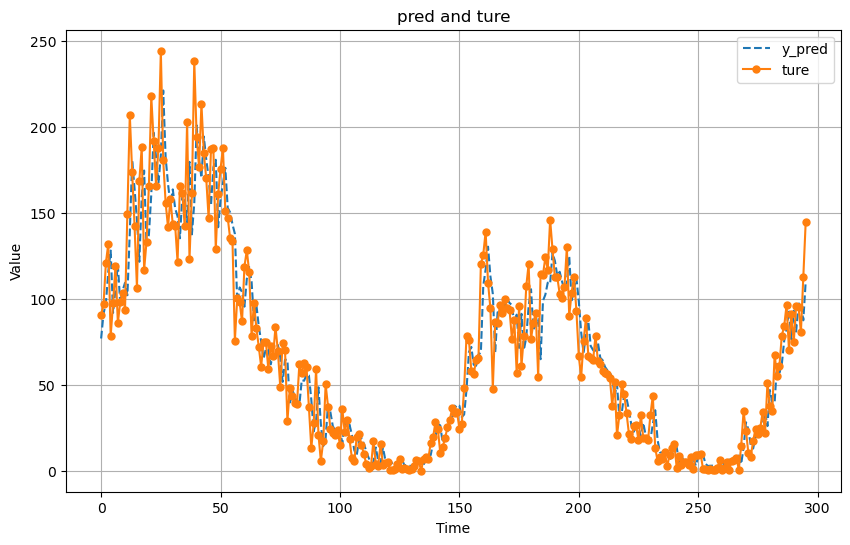

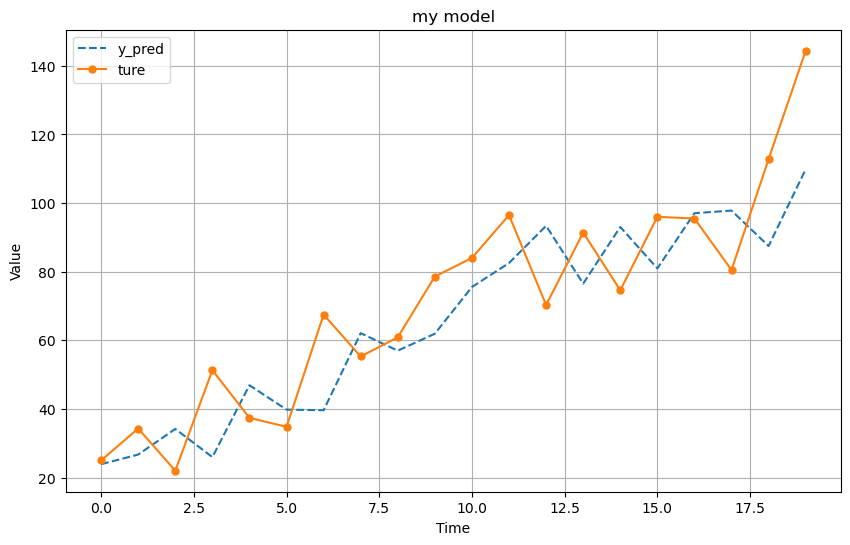

Mean Squared Error: 373.33371415665806


In [ ]:
# 預測結果
y_pred_SP = K_AR_y_pred_SP_package + mean_Bootstrap_data


plt.figure(figsize=(10, 6))
plt.plot(y_pred_SP, label='y_pred', linestyle='--')
plt.plot(test_SP, label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 看最後20天
plt.figure(figsize=(10, 6))
plt.plot(y_pred_SP[len(y_pred_SP)-20:len(y_pred_SP)], label='y_pred', linestyle='--')
plt.plot(test_SP[len(test_SP)-20:len(test_SP)], label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('my model')
plt.grid(True)
plt.show()

# 評估模型性能
mse = np.mean((y_pred_SP - test_SP)**2)
print(f'Mean Squared Error: {mse}')

# MA filter

In [ ]:
# m不能為1

In [ ]:
# 切訓練測試
train_prob = config.train_prob
train_ar1 = df_sunspot[0:int(train_prob*len(df_sunspot))]
test_ar1 = df_sunspot[int(train_prob*len(df_sunspot)):len(df_sunspot)]

# 決定MA_fliter的長度
m = 0
bestK = -100
n_1 = config.n_1
long = len(df_sunspot)
for i in range(2,int(len(train_ar1)*n_1)):
    y_tr = MA_filter(train_ar1,i)  #ma
    kurtosis_value = kurtosis(y_tr)
    # print(kurtosis_value,len(y_tr))
    if abs(3-kurtosis_value)<abs(3-bestK):
        bestK = kurtosis_value
        m = i

print(f"峰度為：{bestK}, m為:{m}, 最大值m為:{int(len(train_ar1)*n_1)}")


峰度為：-0.28514772744620265, m為:2, 最大值m為:118


In [ ]:
# Linear
Linear_train_ar1 = MA_filter(df_sunspot,m)
# non_Linear
non_Linear_train_ar1 = df_sunspot[m-1:long] - Linear_train_ar1


# 切訓練測試
train_prob = config.train_prob

MA_Linear_train_SP = Linear_train_ar1[0:int(train_prob*len(df_sunspot))-m+1]   #### -m+1
MA_Linear_test_SP = Linear_train_ar1[int(train_prob*len(df_sunspot))-m+1:len(df_sunspot)]

MA_non_Linear_train_SP = non_Linear_train_ar1[0:int(train_prob*len(df_sunspot))-m+1]   
MA_non_Linear_test_SP = non_Linear_train_ar1[int(train_prob*len(df_sunspot))-m+1:len(df_sunspot)]


test_SP = df_sunspot[int(train_prob*len(df_sunspot)):len(df_sunspot)]

In [ ]:
non_Linear_train_ar1

array([ 3.55, -4.2 ,  6.2 , ..., -7.5 , 16.15, 15.8 ])

In [ ]:
order = find_order(MA_Linear_train_SP)
order

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

(3, 3)

In [ ]:
# 用ARIMA預測 Linear part
MA_AR_y_pred_SP_package = []
MA_AR_y_pred_SP_CI = []
for i in range(0, len(df_sunspot)-int(train_prob*len(df_sunspot))):
    train = np.concatenate((MA_Linear_train_SP, MA_Linear_test_SP[0:i]))
    ARmodel =  ARIMA(train, order =(order[0], 0, order[1]))
    result = ARmodel.fit()
    MA_AR_y_pred_SP_package.append(result.get_forecast(1).predicted_mean[0])
    MA_AR_y_pred_SP_CI.append(result.get_forecast(1).conf_int()[0])

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ooxx7877\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergence

In [ ]:
# MA_CId_arima = np.array(MA_AR_y_pred_SP_CI)[:,0]
# MA_CIu_arima = np.array(MA_AR_y_pred_SP_CI)[:,1]

In [ ]:
MA_non_Linear_train_SP

array([ 3.55, -4.2 ,  6.2 , ..., -5.7 ,  1.7 ,  8.25])

In [ ]:
len(K_non_Linear_test_SP)

296

In [ ]:
# 製造數據 non_Linear part
window_size = max(order)*10

X,Y = create_dataset(MA_non_Linear_train_SP,window_size)
# print(X,Y)
testX = np.concatenate((Y[len(Y)-window_size:len(Y)], MA_non_Linear_test_SP))
# print(testX)
testX,testY = create_dataset(testX,window_size)
# print(testX,testY)

In [ ]:
# ANN

from sklearn.model_selection import train_test_split
seed_everything(config.seed)

# babu不需要做bootstrap
  
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=config.seed)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(10, activation='relu', input_shape=(window_size,)),
    tf.keras.layers.Dense(1)
])

# 編譯模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 訓練模型
model.fit(X, Y, validation_data=(X_valid, Y_valid), epochs=50, verbose=0)

# 在測試集上進行預測
MA_ANN_y_pred_stock = model.predict(testX)



10/10 [==============================] - 0s 2ms/step


In [ ]:
len(testX)

296

In [ ]:
len(MA_ANN_y_pred_stock[:,0])

295

In [ ]:
# CId = []
# CIu = []
# for i in range(len(Bootstrap_data[0])):
#     CId.append(np.percentile(np.array(Bootstrap_data)[:,i], 2.5))
#     CIu.append(np.percentile(np.array(Bootstrap_data)[:,i], 97.5))
    
# mean_Bootstrap_data = sum(Bootstrap_data)/len(Bootstrap_data)

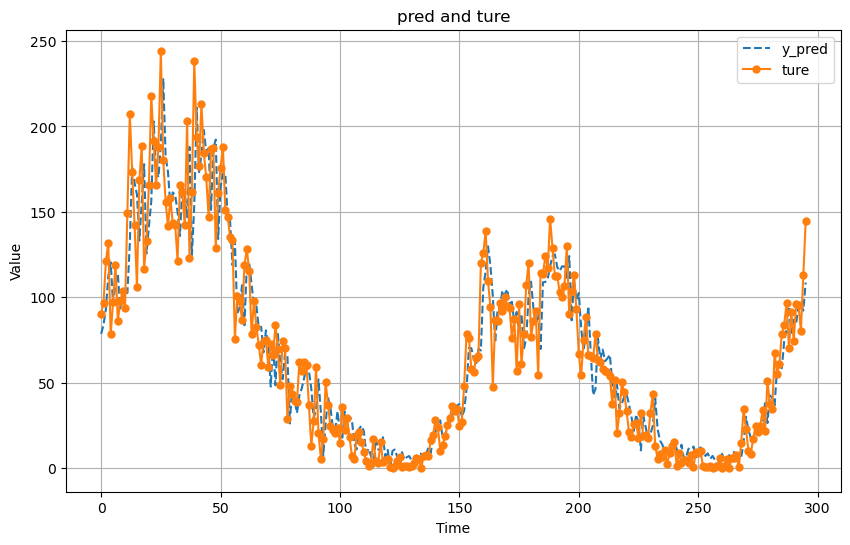

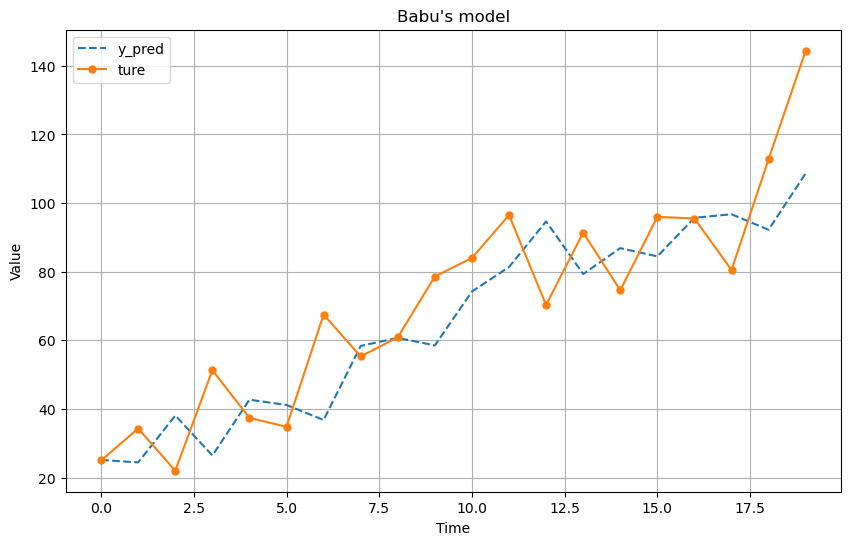

Mean Squared Error: 411.78060888361136


In [ ]:
# 預測結果
MA_y_pred_SP = MA_AR_y_pred_SP_package + MA_ANN_y_pred_stock[:,0]


plt.figure(figsize=(10, 6))
plt.plot(MA_y_pred_SP, label='y_pred', linestyle='--')
plt.plot(test_SP, label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('pred and ture')
plt.grid(True)
plt.show()

# 看最後20天
plt.figure(figsize=(10, 6))
plt.plot(MA_y_pred_SP[len(MA_y_pred_SP)-20:len(MA_y_pred_SP)], label='y_pred', linestyle='--')
plt.plot(test_SP[len(test_SP)-20:len(test_SP)], label='ture', marker='o', markersize=5)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Babu\'s model')
plt.grid(True)
plt.show()

# 評估模型性能
MA_mse = np.mean((MA_y_pred_SP - test_SP)**2)
print(f'Mean Squared Error: {MA_mse}')